**KNN — K Nearest Neighbors**

KNN classifies a new point by looking at its K nearest neighbors and taking majority vote.\
No training happens. KNN memorizes entire dataset and classifies at prediction time.

**Real life example**:\
You move to a new city. You want to know what kind of neighborhood you are in. You look at your 5 nearest neighbors:\
- 4 are doctors
- 1 is engineer

Majority = doctors. So you are in a doctors neighborhood.\
That is KNN. K=5, majority class wins.

**How Distance is Calculated**\
KNN uses Euclidean distance by default:\
**distance = √[(x2-x1)² + (y2-y1)²]**\
Finds K points with smallest distance = nearest neighbors.

K Value — Most Important Decision\
Small K (K=1) → very sensitive — overfitting\
Large K (K=100) → too general — underfitting\
Best K → found by testing different values

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)

# Same dataset as Logistic Regression
np.random.seed(42)
n = 200

data = {
    "age"            : np.random.randint(30, 70, n),
    "cholesterol"    : np.random.randint(150, 300, n),
    "blood_pressure" : np.random.randint(80, 160, n),
    "max_heart_rate" : np.random.randint(100, 200, n),
    "disease"        : np.random.randint(0, 2, n)
}

df = pd.DataFrame(data)

In [ ]:
# Features and target
X = df.drop("disease", axis=1)
y = df["disease"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# Scale — MANDATORY for KNN — distance based algorithm
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

**Why Scaling is MANDATORY for KNN**\
Without scaling:\
age           : 25, 30         — difference of 5\
cholesterol   : 150, 300       — difference of 150

Cholesterol difference (150) dominates age difference (5)\
KNN thinks cholesterol is 30x more important than age\
This is wrong — just different units

With scaling — both treated equally

In [ ]:
# Train and Predict
# K=5 — default
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

predictions = knn.predict(X_test_scaled)

# Evaluate
print(f"Accuracy  : {accuracy_score(y_test, predictions):.4f}")
print(f"Precision : {precision_score(y_test, predictions):.4f}")
print(f"Recall    : {recall_score(y_test, predictions):.4f}")
print(f"F1 Score  : {f1_score(y_test, predictions):.4f}")

Accuracy  : 0.5500
Precision : 0.5417
Recall    : 0.6500
F1 Score  : 0.5909


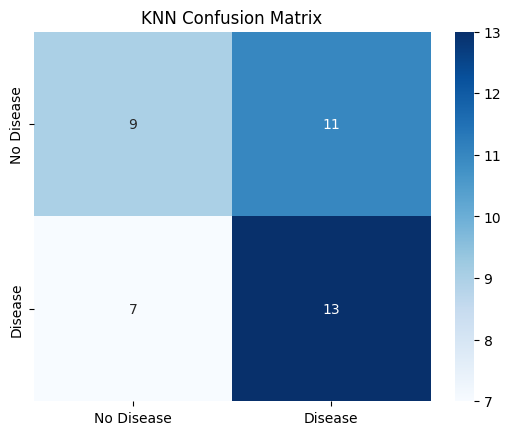



              precision    recall  f1-score   support

  No Disease       0.56      0.45      0.50        20
     Disease       0.54      0.65      0.59        20

    accuracy                           0.55        40
   macro avg       0.55      0.55      0.55        40
weighted avg       0.55      0.55      0.55        40



In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])
plt.title("KNN Confusion Matrix")
plt.show()

print()
print()
# Full report
print(classification_report(y_test, predictions,
      target_names=["No Disease", "Disease"]))

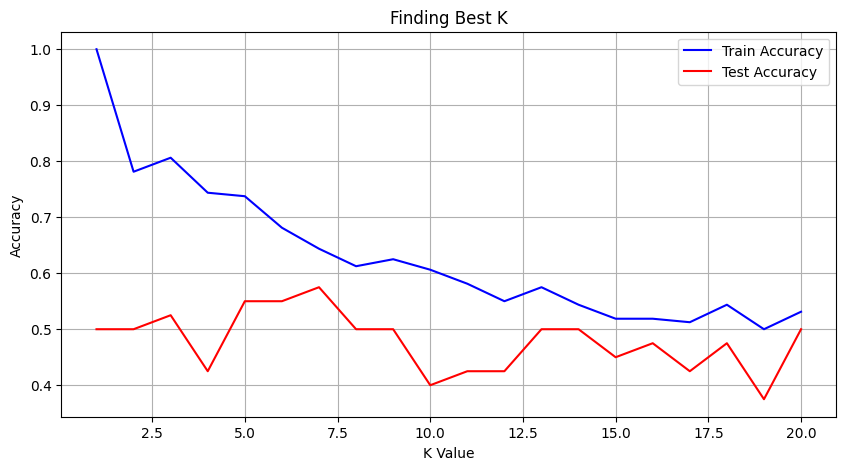

In [ ]:
# Find Best K — Most Important Step
# Test K from 1 to 20 and find best
train_scores = []
test_scores  = []
k_values     = range(1, 21)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    train_scores.append(knn.score(X_train_scaled, y_train))
    test_scores.append(knn.score(X_test_scaled, y_test))

# Plot
plt.figure(figsize=(10, 5))
plt.plot(k_values, train_scores, label="Train Accuracy", color="blue")
plt.plot(k_values, test_scores,  label="Test Accuracy",  color="red")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Finding Best K")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Best K
best_k = k_values[np.argmax(test_scores)]
print(f"Best K : {best_k}")
print(f"Best Test Accuracy : {max(test_scores):.4f}")

# What to look for in graph:

# K=1  → Train accuracy very high, Test low → Overfitting
# K=20 → Both low → Underfitting
# Best K → where test accuracy is highest

# Train Final Model with Best K
# Use best K
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)
final_pred = final_knn.predict(X_test_scaled)

print(f"\nFinal Model — K={best_k}")
print(f"Accuracy  : {accuracy_score(y_test, final_pred):.4f}")
print(f"Recall    : {recall_score(y_test, final_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, final_pred):.4f}")

# Predict New Patient
new_patient = pd.DataFrame([[55, 250, 140, 150]],
              columns=["age", "cholesterol",
                       "blood_pressure", "max_heart_rate"])

new_scaled = scaler.transform(new_patient)
pred       = final_knn.predict(new_scaled)
proba      = final_knn.predict_proba(new_scaled)

print(f"Prediction  : {'Disease' if pred[0]==1 else 'No Disease'}")
print(f"Probability : {proba[0][1]:.4f}")

Best K : 7
Best Test Accuracy : 0.5750

Final Model — K=7
Accuracy  : 0.5750
Recall    : 0.7000
F1 Score  : 0.6222
Prediction  : No Disease
Probability : 0.4286


In [ ]:
# Compare KNN vs Logistic Regression

print("Model Comparison:")
print(f"{'Model':<25} {'Accuracy':<12} {'Recall':<12} {'F1'}")
print("-" * 55)

# Logistic Regression results
lr_model = __import__('sklearn.linear_model',
           fromlist=['LogisticRegression']).LogisticRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred  = lr_model.predict(X_test_scaled)

print(f"{'Logistic Regression':<25}"
      f"{accuracy_score(y_test, lr_pred):<12.4f}"
      f"{recall_score(y_test, lr_pred):<12.4f}"
      f"{f1_score(y_test, lr_pred):.4f}")

print(f"{'KNN (Best K)':<25}"
      f"{accuracy_score(y_test, final_pred):<12.4f}"
      f"{recall_score(y_test, final_pred):<12.4f}"
      f"{f1_score(y_test, final_pred):.4f}")


Model Comparison:
Model                     Accuracy     Recall       F1
-------------------------------------------------------
Logistic Regression      0.4250      0.6000      0.5106
KNN (Best K)             0.5750      0.7000      0.6222
